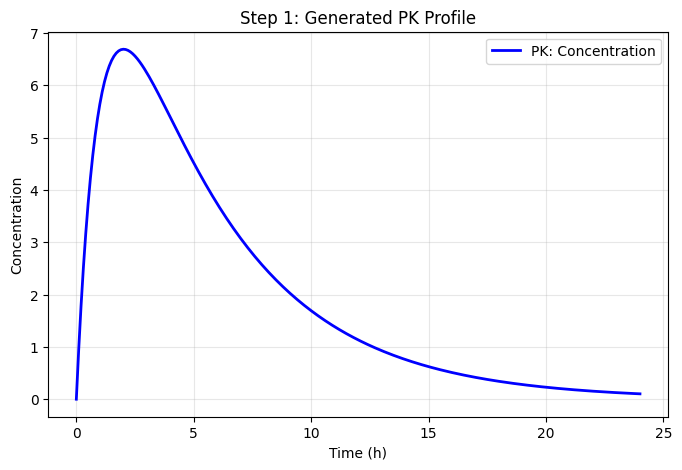

C_max (峰值浓度): 6.6873


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子以保证结果可复现
np.random.seed(42)

# ============================
# 1. 生成 PK 数据 (One-Compartment Model)
# ============================

# 参数设定
D = 100.0       # 剂量 (Dose)
V = 10.0        # 分布容积 (Volume)
ka = 1.0        # 吸收速率常数 (1/h)
ke = 0.2        # 消除速率常数 (1/h)
F = 1.0         # 生物利用度

# 定义时间向量 (0 到 24小时, 241个点)
t = np.linspace(0, 24, 241)

# 计算血药浓度 C(t) - Bateman 公式
# C(t) = (F*D*ka / (V*(ka-ke))) * (exp(-ke*t) - exp(-ka*t))
pre_factor = (F * D * ka) / (V * (ka - ke))
C_t = pre_factor * (np.exp(-ke * t) - np.exp(-ka * t))

# 简单的可视化检查
plt.figure(figsize=(8, 5))
plt.plot(t, C_t, 'b-', linewidth=2, label='PK: Concentration')
plt.title('Step 1: Generated PK Profile')
plt.xlabel('Time (h)')
plt.ylabel('Concentration')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 打印峰值信息
print(f"C_max (峰值浓度): {np.max(C_t):.4f}")

正在模拟 20 位受试者...


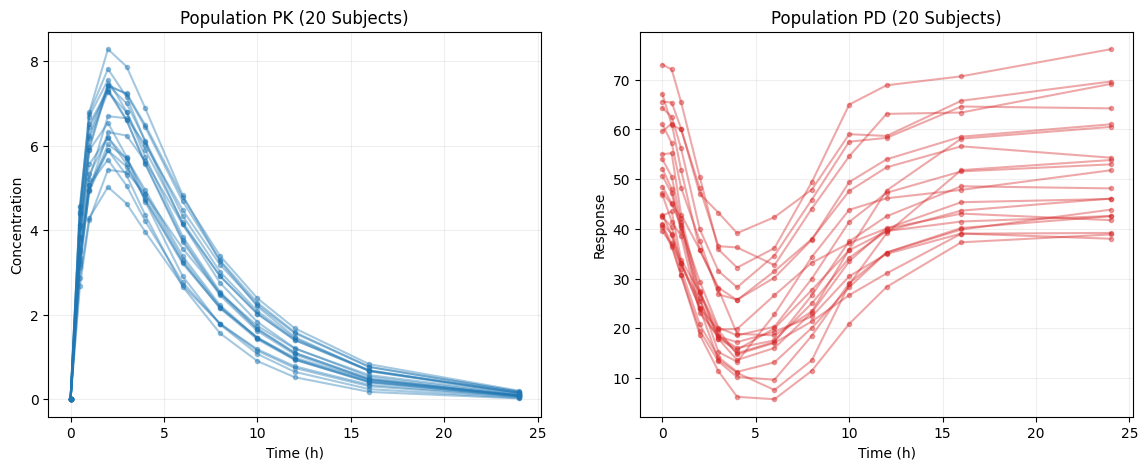

总样本量: 240 (20人 x 12点)
数据列: Time | Concentration | Response


In [2]:
from scipy.integrate import odeint
from scipy.interpolate import interp1d

# ============================
# 2. 生成群体 PK/PD 数据 (Population PK/PD)
# ============================

# --- A. 设定群体参数 (Population Parameters) ---
n_subjects = 20  # 受试者人数
t_clinical = np.array([0, 0.5, 1.0, 2.0, 3.0, 4.0, 6.0, 8.0, 10.0, 12.0, 16.0, 24.0]) # 稀疏采样点

# 典型值 (Typical Values, TV)
tv_params = {
    'D': 100.0, 'V': 10.0, 'ka': 1.0, 'ke': 0.2,   # PK 参数
    'kin': 25.0, 'kout': 0.5, 'imax': 1.0, 'ec50': 4.0, 'gamma': 3.0 # PD 参数
}

# 个体变异 (Inter-Individual Variability, IIV) - 设定为 10%-20% 的变异系数

iiv_std = 0.15 # 15% 变异

# --- B. 模拟过程 ---
all_data_list = []

# 定义 PD ODE (复用之前的逻辑)
def pd_ode_subject(R, t, kin, kout, imax, ec50, gamma, C_func):
    c_curr = max(C_func(t), 0.0)
    hill = (c_curr**gamma) / (ec50**gamma + c_curr**gamma)
    return kin * (1.0 - imax * hill) - kout * R

# 可视化准备
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

print(f"正在模拟 {n_subjects} 位受试者...")

for i in range(n_subjects):
    # 1. 为该受试者生成个体参数 (Params_i = TV * exp(eta))
    p = {k: v * np.exp(np.random.normal(0, iiv_std)) for k, v in tv_params.items()}
    # 修正：Dose 通常是固定的，Hill系数 gamma 变异通常较小
    p['D'] = tv_params['D']
    p['gamma'] = tv_params['gamma']

    # 2. 计算该受试者的 PK (Bateman函数)
    pre = (p['D'] * p['ka']) / (p['V'] * (p['ka'] - p['ke']))
    C_dense = pre * (np.exp(-p['ke'] * t) - np.exp(-p['ka'] * t)) # 密集曲线用于插值
    C_interp_subj = interp1d(t, C_dense, kind='cubic', fill_value="extrapolate")

    # 3. 计算该受试者的 PD
    R0 = p['kin'] / p['kout']
    # 解微分方程
    R_dense = odeint(pd_ode_subject, R0, t, args=(p['kin'], p['kout'], p['imax'], p['ec50'], p['gamma'], C_interp_subj)).flatten()

    # 4. 提取临床采样点并加噪
    C_obs = C_interp_subj(t_clinical)
    R_true_loc = interp1d(t, R_dense)(t_clinical)
    # 添加残差误差 (Residual Error)
    R_obs = R_true_loc + np.random.normal(0, 0.03 * np.mean(R_dense), size=len(t_clinical))

    # 5. 存储数据 [Time, Conc, Resp]
    subj_data = np.column_stack((t_clinical, C_obs, R_obs))
    all_data_list.append(subj_data)

    # 绘图 (Spaghetti Plot)
    ax1.plot(t_clinical, C_obs, '.-', alpha=0.4, color='tab:blue')
    ax2.plot(t_clinical, R_obs, '.-', alpha=0.4, color='tab:red')

# --- C. 整理最终数据集 ---
# 将所有受试者的数据堆叠在一起
pop_data = np.vstack(all_data_list)

# 绘图装饰
ax1.set_title(f'Population PK ({n_subjects} Subjects)')
ax1.set_xlabel('Time (h)')
ax1.set_ylabel('Concentration')
ax1.grid(True, alpha=0.2)

ax2.set_title(f'Population PD ({n_subjects} Subjects)')
ax2.set_xlabel('Time (h)')
ax2.set_ylabel('Response')
ax2.grid(True, alpha=0.2)
plt.show()

print(f"总样本量: {pop_data.shape[0]} (20人 x 12点)")
print(f"数据列: Time | Concentration | Response")

In [3]:
# ============================
# 3. 导包，项目准备
# ============================
import torch
import torch.nn as nn
from deepymod import DeepMoD, Library
from deepymod.data import Dataset, get_train_test_loader
from deepymod.model.func_approx import NN
from deepymod.model.constraint import LeastSquares
from deepymod.model.sparse_estimators import Threshold
from deepymod.training import train
from deepymod.training.sparsity_scheduler import TrainTestPeriodic
from typing import Tuple
from deepymod.utils.types import TensorList
from torch.autograd import grad

# 配置设备
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Running on {device}")

D:\PycharmProjects\DeePyMoD\src\deepymod\__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


Running on cuda


Preprocessing data
Dataset is using device:  cuda
Batch 0 Input (Time) shape: torch.Size([192, 1])
Batch 0 Target (R, C) shape: torch.Size([192, 2])


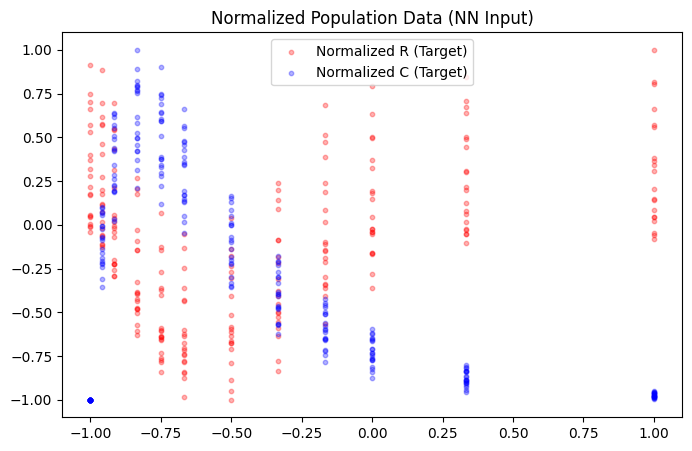

In [4]:
# ============================
# 4. 数据预处理与加载
# ============================

def load_population_data():
    # 输入: Time [N, 1]
    # 我们使用 float32 这里的 N = 240
    t_tensor = torch.tensor(pop_data[:, 0:1], dtype=torch.float32)

    # 目标: [Response, Concentration] [N, 2]
    # 我们让神经网络同时拟合 R 和 C
    # Index 0: Response (R)
    # Index 1: Concentration (C)
    y_tensor = torch.tensor(pop_data[:, [2, 1]], dtype=torch.float32)

    return t_tensor, y_tensor

# 初始化 Dataset
# normalize_coords=True: 时间归一化到 [-1, 1]
# normalize_data=True: 响应和浓度归一化，这对收敛至关重要
dataset = Dataset(
    load_population_data,
    preprocess_kwargs={
        "noise_level": 0.0,
        "normalize_coords": True,
        "normalize_data": True,
    },
    device=device
)

# 划分训练集和测试集
# 现在数据量充足，我们可以留出 20% 作为测试集
train_dataloader, test_dataloader = get_train_test_loader(dataset, train_test_split=0.8)

# 检查一个 Batch
for batch_idx, (input_batch, target_batch) in enumerate(train_dataloader):
    # input_batch: Time
    # target_batch: [R, C]
    if batch_idx == 0:
        print(f"Batch 0 Input (Time) shape: {input_batch.shape}")
        print(f"Batch 0 Target (R, C) shape: {target_batch.shape}")
        break

# 可视化归一化后的数据云
fig, ax = plt.subplots(figsize=(8, 5))
t_norm = dataset.get_coords().cpu()
y_norm = dataset.get_data().cpu()

ax.scatter(t_norm, y_norm[:, 0], s=10, c='r', alpha=0.3, label='Normalized R (Target)')
ax.scatter(t_norm, y_norm[:, 1], s=10, c='b', alpha=0.3, label='Normalized C (Target)')
ax.set_title('Normalized Population Data (NN Input)')
ax.legend()
plt.show()

In [5]:
# ============================
# 5. 构建自动PD建模库 (改进版)
# ============================

class Competitive_Library(Library):
    def __init__(self, include_linear: bool = False) -> None:
        """
        include_linear: 是否额外加入 C 线性项（默认 False，避免与 Hill 重复）
        """
        super().__init__()
        self.include_linear = include_linear

        # 初始化（可学习参数）
        self.hill_ec50 = nn.Parameter(torch.tensor(0.0))  # softplus(0) ≈ 0.69
        self.hill_gamma = nn.Parameter(torch.tensor(1.0)) # softplus(1) ≈ 1.31

    def library(self, input: Tuple[torch.Tensor, torch.Tensor]) -> Tuple[TensorList, TensorList]:
        prediction, data = input
        R = prediction[:, 0:1]
        C = prediction[:, 1:2]

        # 计算导数
        time_deriv_list = []
        for output_idx in range(prediction.shape[1]):
            dy = grad(
                prediction[:, output_idx],
                data,
                grad_outputs=torch.ones_like(prediction[:, output_idx]),
                create_graph=True
            )[0]
            time_deriv_list.append(dy[:, 0:1])

        # --- 准备特征项 ---
        C_safe = torch.relu(C) + 1e-6

        h_ec50 = torch.nn.functional.softplus(self.hill_ec50)
        h_gamma = torch.nn.functional.softplus(self.hill_gamma)
        term_Hill = 1.0 / (1.0 + (h_ec50 / C_safe) ** h_gamma)

        one = torch.ones_like(R)

        # --- 组装 Theta ---
        # 0: Constant
        # 1: R
        # 2: Hill
        # 3: R * Hill
        terms = [
            one,
            R,
            term_Hill,
            R * term_Hill
        ]

        # 可选：加入线性药效项（默认不启用）
        if self.include_linear:
            terms.append(C)

        theta = torch.cat(terms, dim=1)

        return time_deriv_list, [theta, theta]

In [6]:
# ============================
# 6. 配置与初始化模型 (改进版)
# ============================

# 自定义 Ridge 约束器（保持不变）
class Ridge(nn.Module):
    def __init__(self, lam=1e-3) -> None:
        super().__init__()
        self.lam = lam
        self.sparsity_masks = None
        self.coeff_vectors = None

    def forward(self, input: Tuple[TensorList, TensorList]) -> TensorList:
        time_derivs, thetas = input

        # 初始化 Mask
        if self.sparsity_masks is None:
            self.sparsity_masks = [torch.ones(theta.shape[1], dtype=torch.bool).to(theta.device) for theta in thetas]

        # 应用 Mask
        sparse_thetas = [theta[:, mask] for theta, mask in zip(thetas, self.sparsity_masks)]

        # Ridge Regression 拟合
        coeff_vectors = []
        for theta, dt in zip(sparse_thetas, time_derivs):
            XtX = theta.T @ theta
            reg = self.lam * torch.eye(XtX.shape[0]).to(XtX.device)
            Xty = theta.T @ dt
            try:
                w = torch.linalg.solve(XtX + reg, Xty)
            except RuntimeError:
                w = torch.linalg.pinv(XtX + reg) @ Xty
            coeff_vectors.append(w)

        # 恢复完整长度的系数向量
        full_coeffs = []
        for mask, coeff in zip(self.sparsity_masks, coeff_vectors):
            full_c = torch.zeros((mask.shape[0], 1)).to(coeff.device)
            if mask.sum() > 0:
                full_c[mask] = coeff
            full_coeffs.append(full_c)

        self.coeff_vectors = full_coeffs
        return full_coeffs

# 1. 神经网络配置
network = NN(1, [50, 50, 50, 50], 2)

# 2. 库配置（改进版）
library = Competitive_Library(include_linear=False)

# 3. 稀疏估计器
estimator = Threshold(0.1)

# 4. 约束器
constraint = Ridge(lam=1e-3)

# 5. 实例化模型
model = DeepMoD(network, library, estimator, constraint).to(device)

# 6. 优化器：分离 NN 与 Library
optimizer_nn = torch.optim.Adam(
    model.func_approx.parameters(),
    betas=(0.99, 0.999),
    amsgrad=True,
    lr=2e-3
)

optimizer_lib = torch.optim.Adam(
    model.library.parameters(),
    betas=(0.99, 0.999),
    amsgrad=True,
    lr=1e-3
)

print("模型配置完成。")
print(model)
print("\n初始猜测参数 (可学习库参数):")
for name, param in model.named_parameters():
    if 'library' in name:
        print(f"  {name}: {param.data.item():.4f}")

模型配置完成。
DeepMoD(
  (func_approx): NN(
    (network): Sequential(
      (0): Linear(in_features=1, out_features=50, bias=True)
      (1): Tanh()
      (2): Linear(in_features=50, out_features=50, bias=True)
      (3): Tanh()
      (4): Linear(in_features=50, out_features=50, bias=True)
      (5): Tanh()
      (6): Linear(in_features=50, out_features=50, bias=True)
      (7): Tanh()
      (8): Linear(in_features=50, out_features=2, bias=True)
    )
  )
  (library): Competitive_Library()
  (sparse_estimator): Threshold()
  (constraint): Ridge()
)

初始猜测参数 (可学习库参数):
  library.hill_ec50: 0.0000
  library.hill_gamma: 1.0000


In [25]:
import os
import torch.nn.functional as F
from torch.utils.tensorboard import SummaryWriter

# ============================
# 7. 外层交替优化训练
# ============================

log_dir = "./logs/pkpd_population/"
os.makedirs(log_dir, exist_ok=True)
writer = SummaryWriter(log_dir)

def pretrain_nn(model, train_loader, optimizer, writer, n_epochs=1500):
    model.train()
    step = 0
    for epoch in range(n_epochs):
        total_loss = 0.0
        for X, y in train_loader:
            pred, _ = model.func_approx(X)
            loss = torch.mean((pred - y) ** 2)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_loader)
        writer.add_scalar("pretrain_loss", avg_loss, step)
        if epoch % 300 == 0:
            print(f"[Pretrain NN] epoch={epoch}, mse={avg_loss:.4e}")
        step += 1

def finetune_nn(model, train_loader, test_loader, optimizer, writer, n_epochs=100, offset_step=0):
    model.train()
    step = offset_step
    for epoch in range(n_epochs):
        total_loss = 0.0
        for X, y in train_loader:
            pred, _ = model.func_approx(X)
            loss = torch.mean((pred - y) ** 2)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_loader)
        writer.add_scalar("finetune_loss", avg_loss, step)

        # 记录 finetune 阶段的验证 MSE
        with torch.no_grad():
            val_mse = 0.0
            for Xv, yv in test_loader:
                predv, _ = model.func_approx(Xv)
                val_mse += torch.mean((predv - yv) ** 2).item()
            val_mse = val_mse / len(test_loader)
        writer.add_scalar("finetune_val_mse", val_mse, step)

        step += 1
    return step

def alternating_fit(model, train_loader, test_loader, optimizer_nn, optimizer_lib, sparsity_estimator, writer, n_outer=4, n_inner=300, nn_finetune_epochs=100):
    model.train()
    global_step = 0
    finetune_step = 0

    for outer in range(n_outer):
        print(f"\n[Outer Step {outer+1}/{n_outer}]")

        # --- 1) 解冻 NN, 微调若干 epoch ---
        for p in model.func_approx.parameters():
            p.requires_grad = True
        finetune_step = finetune_nn(
            model, train_loader, test_loader, optimizer_nn, writer,
            n_epochs=nn_finetune_epochs, offset_step=finetune_step
        )

        # --- 2) 冻结 NN ---
        for p in model.func_approx.parameters():
            p.requires_grad = False

        # --- 3) 更新稀疏 mask ---
        with torch.enable_grad():
            for X, y in train_loader:
                pred, time_derivs, thetas = model(X)
                break
            masks = sparsity_estimator(thetas, time_derivs)
            model.constraint.sparsity_masks = masks

        # --- 4) 固定 mask，优化库参数 ---
        for inner in range(n_inner):
            mse_sum = 0.0
            reg_sum = 0.0
            loss_sum = 0.0
            n_batches = 0

            for X, y in train_loader:
                pred, time_derivs, thetas = model(X)

                mse = torch.mean((pred - y) ** 2)

                reg = torch.mean(torch.stack([
                    torch.mean((dt - theta @ coeff) ** 2)
                    for dt, theta, coeff in zip(
                        time_derivs,
                        thetas,
                        model.constraint_coeffs(sparse=True, scaled=False)
                    )
                ]))

                loss = mse + reg
                optimizer_lib.zero_grad()
                loss.backward()
                optimizer_lib.step()

                mse_sum += mse.item()
                reg_sum += reg.item()
                loss_sum += loss.item()
                n_batches += 1

            avg_mse = mse_sum / n_batches
            avg_reg = reg_sum / n_batches
            avg_loss = loss_sum / n_batches

            writer.add_scalar("loss", avg_loss, global_step)
            writer.add_scalar("mse_0", avg_mse, global_step)
            writer.add_scalar("reg_0", avg_reg, global_step)

            # 验证集 MSE
            with torch.no_grad():
                val_mse = 0.0
                for Xv, yv in test_loader:
                    predv, _ = model.func_approx(Xv)
                    val_mse += torch.mean((predv - yv) ** 2).item()
                val_mse = val_mse / len(test_loader)
            writer.add_scalar("MSE_test_0", val_mse, global_step)

            global_step += 1

        print(f"  [Inner End] loss={avg_loss:.4e} | mse={avg_mse:.4e} | reg={avg_reg:.4e}")

# ============================
# A. 预训练 NN
# ============================
print("开始预训练 NN...")
pretrain_nn(model, train_dataloader, optimizer_nn, writer, n_epochs=1500)

# ============================
# B. 外层交替优化
# ============================
print("开始外层交替优化...")
alternating_fit(
    model,
    train_dataloader,
    test_dataloader,
    optimizer_nn,
    optimizer_lib,
    estimator,
    writer,
    n_outer=4,
    n_inner=300,
    nn_finetune_epochs=100
)

writer.close()
print("\n训练结束！")

# --- 查看最终学到的药理学参数 ---
print("\n[最终参数识别结果]")
print("-" * 30)

lib = model.library

def to_physical(raw_param):
    return F.softplus(raw_param).item()

print(f"Hill Model (核心候选):")
print(f"  Gamma (Hill系数) : {to_physical(lib.hill_gamma):.4f}")
print(f"  EC50            : {to_physical(lib.hill_ec50):.4f}")
print("-" * 30)

开始预训练 NN...
[Pretrain NN] epoch=0, mse=5.0836e-02
[Pretrain NN] epoch=300, mse=5.0836e-02
[Pretrain NN] epoch=600, mse=5.0836e-02
[Pretrain NN] epoch=900, mse=5.0836e-02
[Pretrain NN] epoch=1200, mse=5.0836e-02
开始外层交替优化...

[Outer Step 1/4]
  [Inner End] loss=2.5958e+01 | mse=5.0831e-02 | reg=2.5907e+01

[Outer Step 2/4]
  [Inner End] loss=2.6047e+01 | mse=5.0827e-02 | reg=2.5996e+01

[Outer Step 3/4]
  [Inner End] loss=2.6121e+01 | mse=5.0823e-02 | reg=2.6071e+01

[Outer Step 4/4]
  [Inner End] loss=2.6184e+01 | mse=5.0819e-02 | reg=2.6133e+01

训练结束！

[最终参数识别结果]
------------------------------
Hill Model (核心候选):
  Gamma (Hill系数) : 0.7157
  EC50            : 0.3402
------------------------------


In [26]:
# ============================
# 8. 结果解释与方程重建 (改进版)
# ============================

# 动态构造名称列表
library_names = [
    "1",              # 0
    "R",              # 1
    "Hill_Term",      # 2
    "R*Hill_Term"     # 3
]

# 如果 include_linear=True，则追加线性项
if hasattr(model.library, "include_linear") and model.library.include_linear:
    library_names.append("C")

print("正在解码发现的方程...\n")

# 获取 dR/dt 的稀疏回归结果
mask_R = model.constraint.sparsity_masks[0].detach().cpu().numpy()
coeffs_R = model.constraint.coeff_vectors[0].detach().cpu().numpy().flatten()

print(f"针对 dR/dt (响应变化率) 的稀疏回归结果:")
print("-" * 50)

found_terms = []
for idx, (is_active, coeff) in enumerate(zip(mask_R, coeffs_R)):
    if idx >= len(library_names):
        break
    term_name = library_names[idx]

    if is_active:
        sign = "+" if coeff >= 0 else ""
        term_str = f"{sign} {coeff:.4f} * [{term_name}]"
        found_terms.append(term_str)
        print(f"[选中] {term_name:<15} 系数: {coeff:.4f}")

print("-" * 50)
print("最终发现的方程形式 (归一化空间):")
equation = "dR/dt = " + " ".join(found_terms)
print(equation)

# --- 验证逻辑 ---
# 真实的物理方程结构: dR/dt = Kin - Kout*R - (Kin*Imax)*Hill
has_hill = mask_R[2] or mask_R[3]

print("\n[AI 诊断]")
if has_hill:
    print("SUCCESS: 模型使用了 Hill 机制。")
    print("       请检查上方的 Gamma 和 EC50 值：")
    print("       - 如果 Gamma ≈ 1, 则为 Emax 模型。")
    print("       - 如果 Gamma > 1, 则为 Sigmoid 模型 (您的真实情况)。")
    print("       - 如果 EC50 极大, 则退化为线性模型。")
else:
    print("FAILURE: 未选中任何药物效应项 (这不太可能发生)。")

正在解码发现的方程...

针对 dR/dt (响应变化率) 的稀疏回归结果:
--------------------------------------------------
[选中] 1               系数: 0.8483
[选中] R               系数: -1.1982
[选中] Hill_Term       系数: -11.3490
[选中] R*Hill_Term     系数: -11.4678
--------------------------------------------------
最终发现的方程形式 (归一化空间):
dR/dt = + 0.8483 * [1]  -1.1982 * [R]  -11.3490 * [Hill_Term]  -11.4678 * [R*Hill_Term]

[AI 诊断]
SUCCESS: 模型使用了 Hill 机制。
       请检查上方的 Gamma 和 EC50 值：
       - 如果 Gamma ≈ 1, 则为 Emax 模型。
       - 如果 Gamma > 1, 则为 Sigmoid 模型 (您的真实情况)。
       - 如果 EC50 极大, 则退化为线性模型。


使用最新 event 文件: ./logs/pkpd_population/events.out.tfevents.1770350167.Du-Power.24852.3
可用 tags: ['pretrain_loss', 'finetune_loss', 'finetune_val_mse', 'loss', 'mse_0', 'reg_0', 'MSE_test_0']


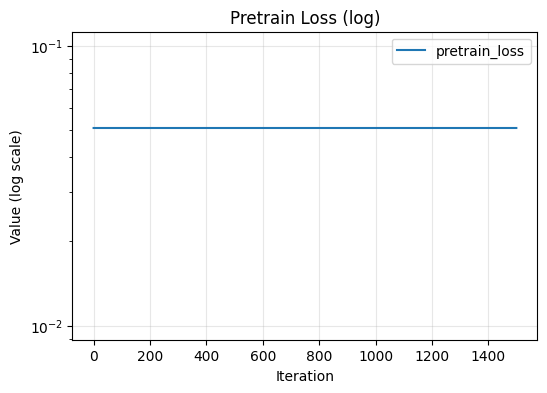

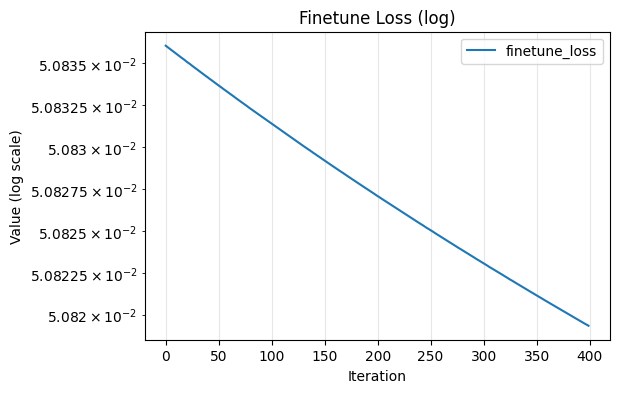

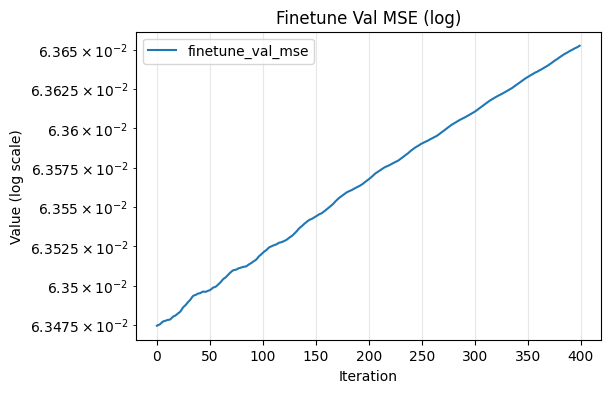

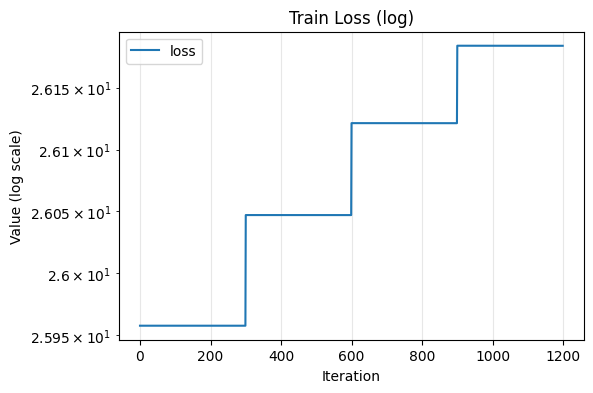

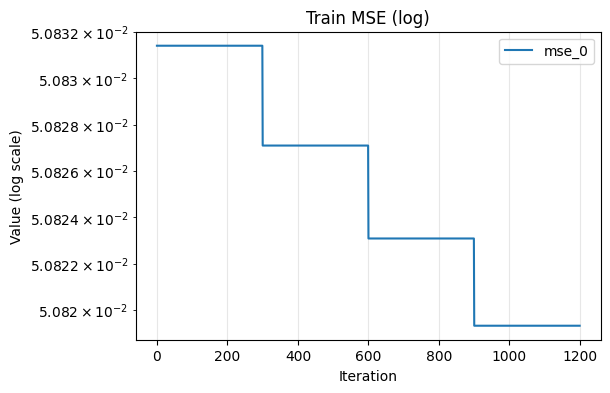

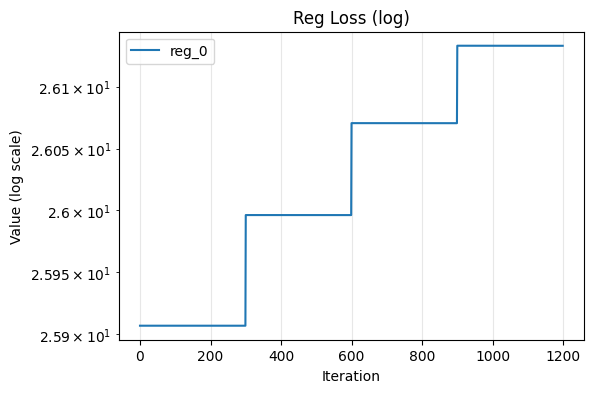

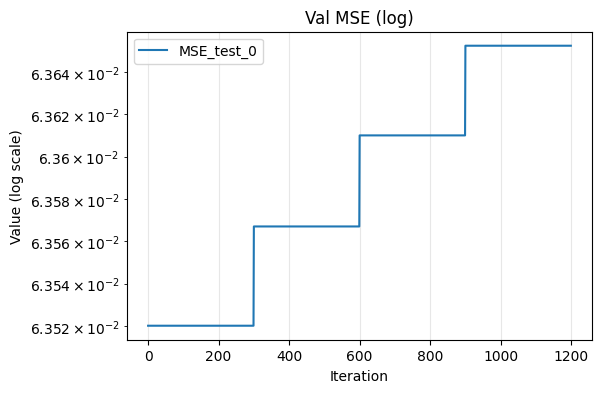

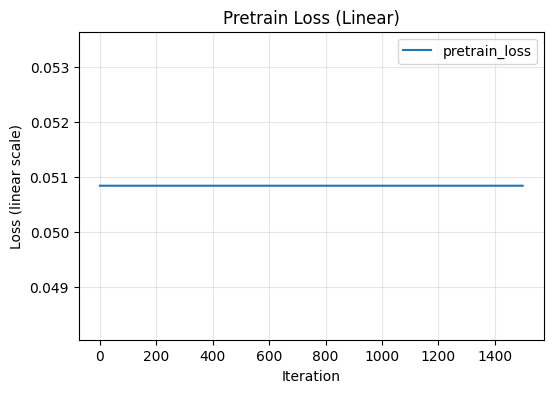

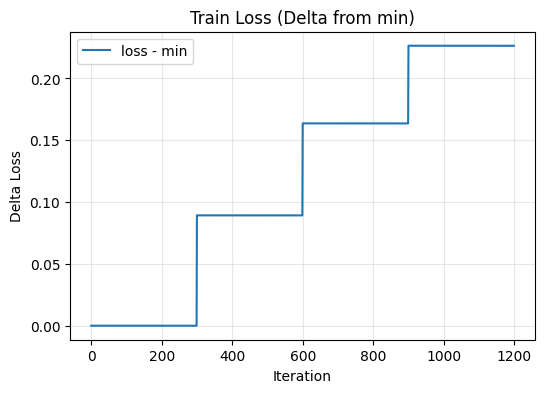

In [27]:
# ============================
# 9. 拆分输出曲线 + 线性坐标 + Δ损失 (含 finetune_val_mse)
# ============================

import os
import pandas as pd
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# 找到最新的 event 文件
event_files = []
for root, _, files in os.walk(log_dir):
    for f in files:
        if f.startswith("events"):
            event_files.append(os.path.join(root, f))

if not event_files:
    raise FileNotFoundError("未找到 TensorBoard event 文件，请先运行训练。")

latest_event = max(event_files, key=os.path.getmtime)
print(f"使用最新 event 文件: {latest_event}")

# 读取 scalars
ea = EventAccumulator(latest_event)
ea.Reload()

tags = ea.Tags()["scalars"]
print("可用 tags:", tags)

# 每个 tag 用自己的 step 作为 index，再外连接合并
series_list = []
for tag in tags:
    events = ea.Scalars(tag)
    steps = [e.step for e in events]
    values = [e.value for e in events]
    series_list.append(pd.Series(values, index=steps, name=tag))

history = pd.concat(series_list, axis=1).sort_index()

# 逐条绘制（log scale）
plot_keys = [
    ("pretrain_loss", "Pretrain Loss (log)"),
    ("finetune_loss", "Finetune Loss (log)"),
    ("finetune_val_mse", "Finetune Val MSE (log)"),
    ("loss", "Train Loss (log)"),
    ("mse_0", "Train MSE (log)"),
    ("reg_0", "Reg Loss (log)"),
    ("L1", "L1 Norm (log)"),
    ("MSE_test_0", "Val MSE (log)"),
]

for key, title in plot_keys:
    if key in history:
        plt.figure(figsize=(6, 4))
        plt.plot(history.index, history[key], label=key)
        plt.yscale("log")
        plt.xlabel("Iteration")
        plt.ylabel("Value (log scale)")
        plt.title(title)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

# 线性坐标（pretrain）
if "pretrain_loss" in history:
    plt.figure(figsize=(6, 4))
    plt.plot(history.index, history["pretrain_loss"], label="pretrain_loss")
    plt.xlabel("Iteration")
    plt.ylabel("Loss (linear scale)")
    plt.title("Pretrain Loss (Linear)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Δ损失（放大 train loss 细微变化）
if "loss" in history:
    plt.figure(figsize=(6, 4))
    plt.plot(history.index, history["loss"] - history["loss"].min(), label="loss - min")
    plt.xlabel("Iteration")
    plt.ylabel("Delta Loss")
    plt.title("Train Loss (Delta from min)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


[当前发现的 PD 公式（归一化空间）]
------------------------------------------------------------
dR/dt = + 0.8483 * [1]  -1.1982 * [R]  -11.3490 * [Hill_Term]  -11.4678 * [R*Hill_Term]

[Hill_Term 参数]
------------------------------------------------------------
EC50 (norm) = 0.340183
EC50 (phys) = 5.551176
gamma       = 0.715652

[原始建模方程 (真实方程)]
------------------------------------------------------------
dR/dt = Kin - (Kin * Imax) * [ C^gamma / (EC50^gamma + C^gamma) ] - Kout * R


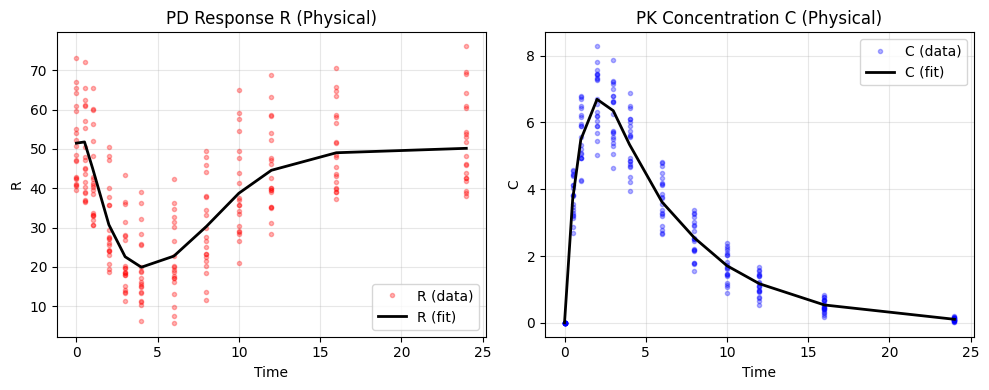


[标准 Hill 形式拟合 (物理尺度)]
------------------------------------------------------------
Kin  = 36.149534
Kout = 0.506383
Imax = 1.489073
EC50 = 5.551176
gamma= 0.715652

[还原方程 (物理尺度)]
------------------------------------------------------------
dR/dt = Kin - (Kin*Imax) * [ C^gamma / (EC50^gamma + C^gamma) ] - Kout * R


In [30]:
# ============================
# 10. 输出PD公式 + Hill参数 + 标准方程 + 反归一化 + 曲线
# ============================

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# --- 0) 反归一化工具 ---
def denorm(x_norm, x_min, x_max):
    return (x_norm + 1.0) * 0.5 * (x_max - x_min) + x_min

def norm_scale(x_min, x_max):
    return (x_max - x_min) / 2.0  # 归一化线性尺度

# 取原始数据范围（来自 pop_data）
t_min, t_max = pop_data[:, 0].min(), pop_data[:, 0].max()
c_min, c_max = pop_data[:, 1].min(), pop_data[:, 1].max()
r_min, r_max = pop_data[:, 2].min(), pop_data[:, 2].max()

a_t = norm_scale(t_min, t_max)
a_c = norm_scale(c_min, c_max)
a_r = norm_scale(r_min, r_max)

# --- 1) 输出归一化空间公式 ---
print("\n[当前发现的 PD 公式（归一化空间）]")
print("-" * 60)

mask_R = model.constraint.sparsity_masks[0].detach().cpu().numpy()
coeffs_R = model.constraint.coeff_vectors[0].detach().cpu().numpy().flatten()

terms = []
for idx, (is_active, coeff) in enumerate(zip(mask_R, coeffs_R)):
    if idx >= len(library_names):
        break
    if is_active:
        sign = "+" if coeff >= 0 else ""
        terms.append(f"{sign} {coeff:.4f} * [{library_names[idx]}]")

equation = "dR/dt = " + " ".join(terms) if terms else "dR/dt = 0"
print(equation)

# --- 2) Hill 参数（反归一化） ---
print("\n[Hill_Term 参数]")
print("-" * 60)
if hasattr(model.library, "hill_ec50") and hasattr(model.library, "hill_gamma"):
    ec50_norm = F.softplus(model.library.hill_ec50).item()
    gamma = F.softplus(model.library.hill_gamma).item()
    ec50_phys = denorm(ec50_norm, c_min, c_max)  # 反归一化
    print(f"EC50 (norm) = {ec50_norm:.6f}")
    print(f"EC50 (phys) = {ec50_phys:.6f}")
    print(f"gamma       = {gamma:.6f}")
else:
    ec50_phys = None
    gamma = None
    print("当前 library 中未检测到 hill_ec50 / hill_gamma 参数")

# --- 3) 原始建模方程 ---
print("\n[原始建模方程 (真实方程)]")
print("-" * 60)
print("dR/dt = Kin - (Kin * Imax) * [ C^gamma / (EC50^gamma + C^gamma) ] - Kout * R")

# --- 4) 反归一化拟合曲线 + 计算 dR/dt ---
model.eval()

# 预测曲线（��需要梯度）
with torch.no_grad():
    t_norm = dataset.get_coords()
    y_norm = dataset.get_data()
    pred_norm, _ = model.func_approx(t_norm)

# 计算导数（需要梯度）
with torch.enable_grad():
    t_norm_grad = dataset.get_coords().detach().clone().requires_grad_(True)
    pred_norm_grad, coords = model.func_approx(t_norm_grad)
    time_derivs, _ = model.library((pred_norm_grad, coords))
    dRdt_norm = time_derivs[0].detach().cpu().numpy().flatten()

t_norm_np = t_norm.cpu().numpy().flatten()
pred_norm_np = pred_norm.cpu().numpy()
y_norm_np = y_norm.cpu().numpy()

# 反归一化
t_phys = denorm(t_norm_np, t_min, t_max)
R_phys = denorm(pred_norm_np[:, 0], r_min, r_max)
C_phys = denorm(pred_norm_np[:, 1], c_min, c_max)

# 原始数据（反归一化）
R_data = denorm(y_norm_np[:, 0], r_min, r_max)
C_data = denorm(y_norm_np[:, 1], c_min, c_max)

# 排序便于画图
idx_sort = np.argsort(t_phys)
t_sorted = t_phys[idx_sort]
R_sorted = R_phys[idx_sort]
C_sorted = C_phys[idx_sort]
R_data_sorted = R_data[idx_sort]
C_data_sorted = C_data[idx_sort]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(t_sorted, R_data_sorted, 'r.', alpha=0.3, label='R (data)')
plt.plot(t_sorted, R_sorted, 'k-', linewidth=2, label='R (fit)')
plt.title("PD Response R (Physical)")
plt.xlabel("Time")
plt.ylabel("R")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(t_sorted, C_data_sorted, 'b.', alpha=0.3, label='C (data)')
plt.plot(t_sorted, C_sorted, 'k-', linewidth=2, label='C (fit)')
plt.title("PK Concentration C (Physical)")
plt.xlabel("Time")
plt.ylabel("C")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- 5) 标准 Hill 形式拟合（物理尺度） ---
# dR/dt = (a_r / a_t) * dR_norm/dt_norm
dRdt_phys = (a_r / a_t) * dRdt_norm

if ec50_phys is not None and gamma is not None:
    C_safe = np.clip(C_phys, 1e-6, None)
    hill_phys = (C_safe ** gamma) / (ec50_phys ** gamma + C_safe ** gamma)

    # 线性拟合：dR/dt = Kin - Kout*R - (Kin*Imax)*Hill
    X = np.column_stack([np.ones_like(R_phys), -R_phys, -hill_phys])
    coef, *_ = np.linalg.lstsq(X, dRdt_phys, rcond=None)
    Kin, Kout, KinImax = coef[0], coef[1], coef[2]
    Imax = (KinImax / Kin) if abs(Kin) > 1e-12 else np.nan

    print("\n[标准 Hill 形式拟合 (物理尺度)]")
    print("-" * 60)
    print(f"Kin  = {Kin:.6f}")
    print(f"Kout = {Kout:.6f}")
    print(f"Imax = {Imax:.6f}")
    print(f"EC50 = {ec50_phys:.6f}")
    print(f"gamma= {gamma:.6f}")

    print("\n[还原方程 (物理尺度)]")
    print("-" * 60)
    print("dR/dt = Kin - (Kin*Imax) * [ C^gamma / (EC50^gamma + C^gamma) ] - Kout * R")
else:
    print("\n[标准 Hill 形式拟合] 失败：缺少 EC50/gamma 参数")

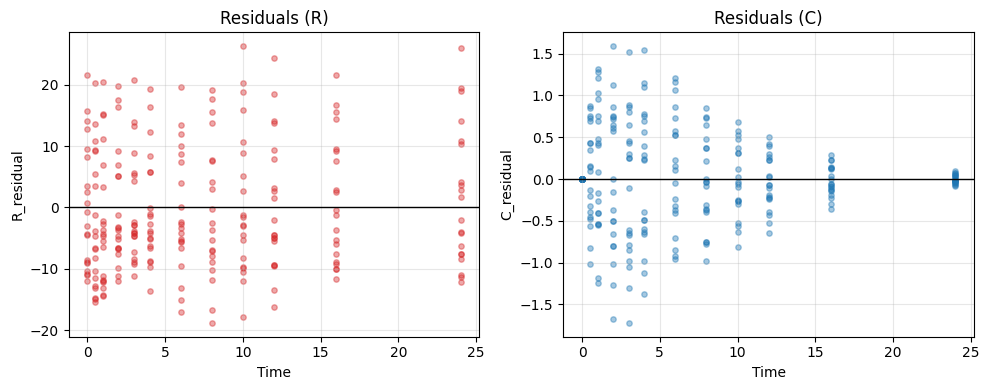

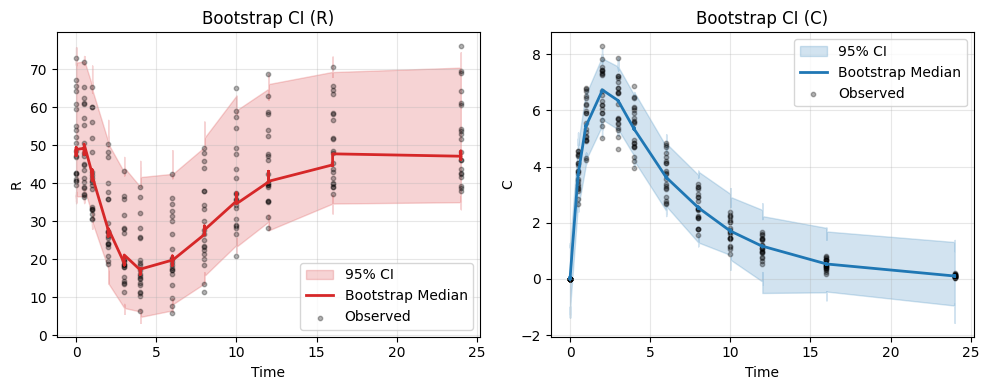

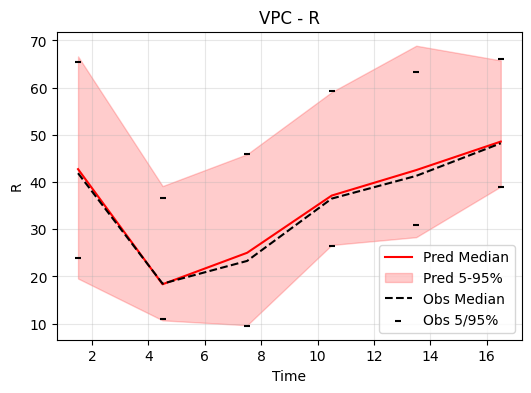

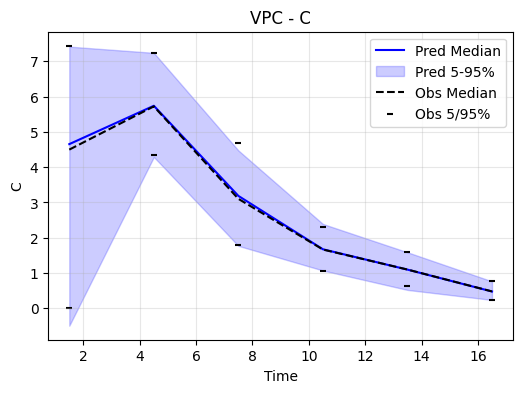

In [31]:
# ============================
# 11. 模型诊断图：残差图 / Bootstrap / VPC
# ============================

import numpy as np
import matplotlib.pyplot as plt

# ---------- 准备数据（物理尺度） ----------
t_norm = dataset.get_coords().cpu().numpy().flatten()
y_norm = dataset.get_data().cpu().numpy()
pred_norm = pred_norm_np  # 来自第10格

# 反归一化
t_phys = denorm(t_norm, t_min, t_max)
R_data = denorm(y_norm[:, 0], r_min, r_max)
C_data = denorm(y_norm[:, 1], c_min, c_max)

R_pred = denorm(pred_norm[:, 0], r_min, r_max)
C_pred = denorm(pred_norm[:, 1], c_min, c_max)

# 残差
res_R = R_data - R_pred
res_C = C_data - C_pred

# ---------- 1) 残差图 ----------
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(t_phys, res_R, s=15, alpha=0.4, color='tab:red')
plt.axhline(0, color='k', linewidth=1)
plt.title("Residuals (R)")
plt.xlabel("Time")
plt.ylabel("R_residual")
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(t_phys, res_C, s=15, alpha=0.4, color='tab:blue')
plt.axhline(0, color='k', linewidth=1)
plt.title("Residuals (C)")
plt.xlabel("Time")
plt.ylabel("C_residual")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ---------- 2) Bootstrap 置信带 ----------
# 用残差重采样生成多条拟合曲线
n_boot = 200
rng = np.random.default_rng(42)

# 对每个时间点重采样残差
boot_R = np.zeros((n_boot, len(R_pred)))
boot_C = np.zeros((n_boot, len(C_pred)))
for i in range(n_boot):
    resampled_R = rng.choice(res_R, size=len(res_R), replace=True)
    resampled_C = rng.choice(res_C, size=len(res_C), replace=True)
    boot_R[i] = R_pred + resampled_R
    boot_C[i] = C_pred + resampled_C

# 计算置信带（2.5% / 50% / 97.5%）
def band_stats(arr):
    return np.percentile(arr, [2.5, 50, 97.5], axis=0)

R_p2, R_p50, R_p97 = band_stats(boot_R)
C_p2, C_p50, C_p97 = band_stats(boot_C)

# 排序画图
idx_sort = np.argsort(t_phys)
t_sorted = t_phys[idx_sort]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.fill_between(t_sorted, R_p2[idx_sort], R_p97[idx_sort], color='tab:red', alpha=0.2, label='95% CI')
plt.plot(t_sorted, R_p50[idx_sort], color='tab:red', linewidth=2, label='Bootstrap Median')
plt.scatter(t_sorted, R_data[idx_sort], s=10, alpha=0.3, color='k', label='Observed')
plt.title("Bootstrap CI (R)")
plt.xlabel("Time")
plt.ylabel("R")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.fill_between(t_sorted, C_p2[idx_sort], C_p97[idx_sort], color='tab:blue', alpha=0.2, label='95% CI')
plt.plot(t_sorted, C_p50[idx_sort], color='tab:blue', linewidth=2, label='Bootstrap Median')
plt.scatter(t_sorted, C_data[idx_sort], s=10, alpha=0.3, color='k', label='Observed')
plt.title("Bootstrap CI (C)")
plt.xlabel("Time")
plt.ylabel("C")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ---------- 3) VPC 检验 ----------
# 基于残差重采样生成预测分位带，再与观测分位比较
# 采用时间分箱
n_bins = 8
bins = np.linspace(t_phys.min(), t_phys.max(), n_bins + 1)

def vpc_summary(t, y, n_sim=200):
    # 每个 bin: 观测 5/50/95 分位，预测 5/50/95 分位
    obs_q = []
    pred_q = []
    bin_centers = []
    for i in range(n_bins):
        mask = (t >= bins[i]) & (t < bins[i + 1])
        if np.sum(mask) < 5:
            continue
        bin_centers.append(0.5 * (bins[i] + bins[i + 1]))

        # 观测分位
        obs_q.append(np.percentile(y[mask], [5, 50, 95]))

        # 预测分位：通过 bootstrap 残差生成
        sim_vals = []
        for _ in range(n_sim):
            resampled = rng.choice(y[mask] - y_pred[mask], size=np.sum(mask), replace=True)
            sim_vals.append(y_pred[mask] + resampled)
        sim_vals = np.concatenate(sim_vals)
        pred_q.append(np.percentile(sim_vals, [5, 50, 95]))

    return np.array(bin_centers), np.array(obs_q), np.array(pred_q)

# R 通道 VPC
y_pred = R_pred
bin_centers, obs_q, pred_q = vpc_summary(t_phys, R_data)

plt.figure(figsize=(6, 4))
plt.plot(bin_centers, pred_q[:, 1], 'r-', label='Pred Median')
plt.fill_between(bin_centers, pred_q[:, 0], pred_q[:, 2], color='r', alpha=0.2, label='Pred 5-95%')
plt.plot(bin_centers, obs_q[:, 1], 'k--', label='Obs Median')
plt.scatter(bin_centers, obs_q[:, 0], c='k', s=20, label='Obs 5/95%', marker='_')
plt.scatter(bin_centers, obs_q[:, 2], c='k', s=20, marker='_')
plt.title("VPC - R")
plt.xlabel("Time")
plt.ylabel("R")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# C 通道 VPC
y_pred = C_pred
bin_centers, obs_q, pred_q = vpc_summary(t_phys, C_data)

plt.figure(figsize=(6, 4))
plt.plot(bin_centers, pred_q[:, 1], 'b-', label='Pred Median')
plt.fill_between(bin_centers, pred_q[:, 0], pred_q[:, 2], color='b', alpha=0.2, label='Pred 5-95%')
plt.plot(bin_centers, obs_q[:, 1], 'k--', label='Obs Median')
plt.scatter(bin_centers, obs_q[:, 0], c='k', s=20, label='Obs 5/95%', marker='_')
plt.scatter(bin_centers, obs_q[:, 2], c='k', s=20, marker='_')
plt.title("VPC - C")
plt.xlabel("Time")
plt.ylabel("C")
plt.legend()
plt.grid(alpha=0.3)
plt.show()